In [6]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
pip install pandas


  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/fa/9a/31f4983f191af51ab2a8f2d0c7b33dff3a84da26533f982fff02c2f9e28b/pandas-3.0.5-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for numpy>=1.26.0 from https://files.pythonhosted.org/packages/c5/31/7fc6239c12bce7e931463251cca4426c465e1876ba3cc785402ef4dd8f4e/numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for tzdata from https://files.pythonhosted.org/packages/e5/6d/b53b99a9f2766d095985947a5782f1702cabb129a34f7a802d7197af832f/tzdata-2026.3-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB 660.6 kB/s eta 0:00:16
   ---------------------------------------- 0.1/10.0 MB 656.4 kB/s eta 0:00:16
   ---------------------------------------- 0.1/10.0 MB 751.6 kB/s eta 0:00:14
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pandas, numpy, matplotlib


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'pandas,'

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
df = pd.read_csv("../data/crop_recommendation.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,N,P,K,temperature,humidity,ph,rainfall,label
0,79,62,65,30.54,68.48,6.71,49.58,muskmelon
1,92,54,60,29.96,75.30,7.02,43.50,watermelon
2,45,76,48,29.97,89.57,7.32,195.66,papaya
3,66,41,41,23.68,67.55,6.64,148.74,papaya
4,22,144,164,24.45,78.26,5.88,238.62,apple


In [8]:

print("Dataset Shape:", df.shape)

Dataset Shape: (2200, 8)


In [9]:
print(df.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [11]:
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
print(df["label"].value_counts())

label
muskmelon      100
watermelon     100
papaya         100
apple          100
mango          100
mothbeans      100
mungbean       100
lentil         100
blackgram      100
coconut        100
pomegranate    100
coffee         100
maize          100
jute           100
orange         100
chickpea       100
pigeonpeas     100
rice           100
kidneybeans    100
grapes         100
cotton         100
banana         100
Name: count, dtype: int64


In [14]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,52.785000,53.350000,46.223636,26.341518,60.623945,6.545164,118.034950
std,33.326238,29.013996,33.015671,4.626186,19.175758,0.633290,63.285466
min,10.000000,5.000000,10.000000,15.060000,15.130000,5.010000,30.060000
25%,25.000000,38.000000,26.000000,22.870000,45.427500,6.070000,70.152500
50%,38.000000,50.000000,37.000000,26.405000,62.580000,6.545000,96.525000
75%,83.000000,59.000000,52.000000,29.942500,76.155000,7.030000,158.617500
max,140.000000,160.000000,179.000000,34.990000,95.000000,8.000000,299.960000


In [15]:
X = df.drop("label", axis=1)
y = df["label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2200, 7)
Target Shape: (2200,)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

import joblib

In [23]:
%pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
%pip install scikit-learn



  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/3b/67/be3d369f40d8178ba3bd86635d132e08cb5329b023e4669d9426d84bc007/scikit_learn-1.9.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 220.2 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 325.1 kB/s eta 0:00:00
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/7b/91/984aca2


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 7)
Testing data: (440, 7)


In [26]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.775


In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8295454545454546


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7977272727272727


In [29]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [30]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train_encoded
)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test_encoded,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8068181818181818


In [31]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        xgb_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
1,Random Forest,0.829545
3,XGBoost,0.806818
2,SVM,0.797727
0,Decision Tree,0.775000


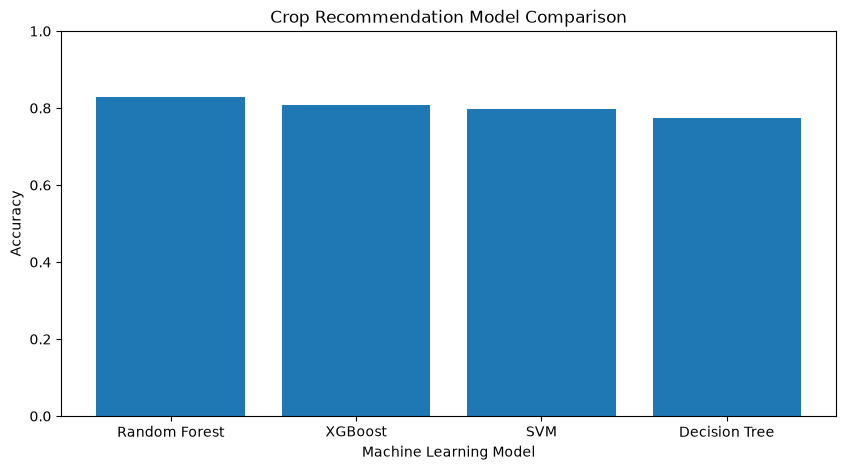

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Crop Recommendation Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [33]:
%pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/bc/be/fa26ed085b41298f64a8f9b7592c671bbf1acc8b0df124c1c5de96b859f8/matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 163.8 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 163.4 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 245.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 263.2 kB/s eta 0:00:00
  Obtaining dependency informa

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       0.90      0.90      0.90        20
   blackgram       0.63      0.60      0.62        20
    chickpea       0.65      0.85      0.74        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.79      0.75      0.77        20
 kidneybeans       0.71      0.60      0.65        20
      lentil       0.91      0.50      0.65        20
       maize       1.00      1.00      1.00        20
       mango       0.95      0.90      0.92        20
   mothbeans       0.57      0.80      0.67        20
    mungbean       0.40      0.40      0.40        20
   muskmelon       0.77      0.85      0.81        20
      orange       0.89      0.80      0.84  

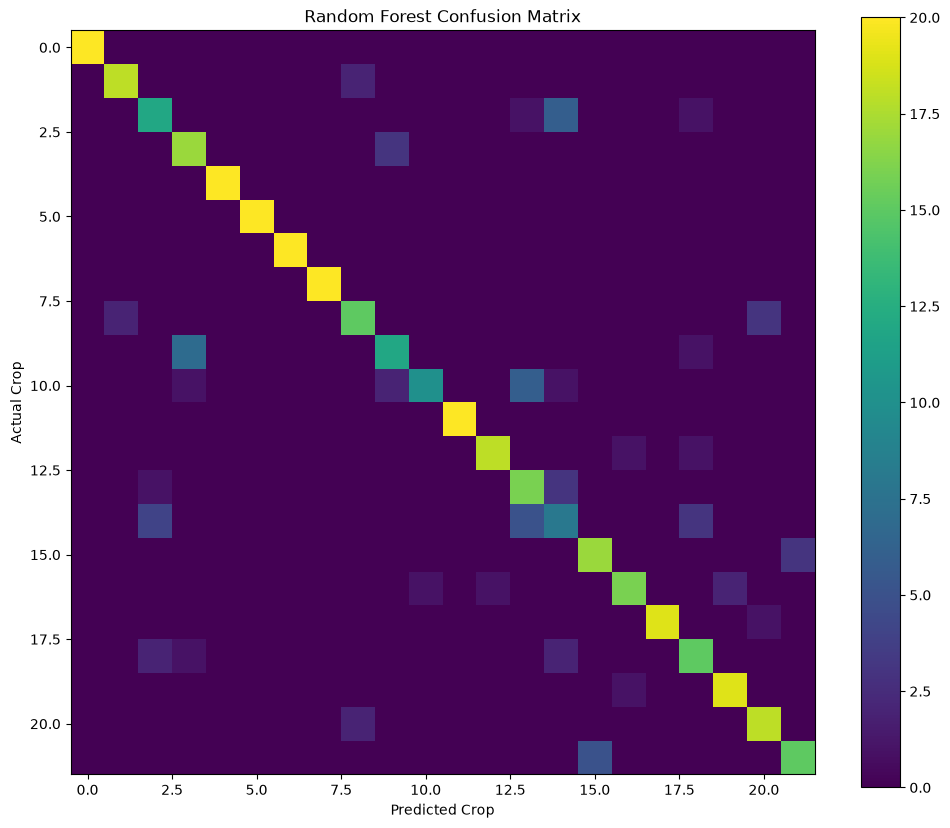

In [36]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.colorbar()

plt.show()

In [37]:
import joblib
from pathlib import Path

model_path = Path("../models/crop_model.pkl")

joblib.dump(rf_model, model_path)

print("Model saved successfully!")
print("Saved at:", model_path.resolve())

Model saved successfully!
Saved at: C:\Users\jahna\OneDrive\Desktop\Smart-Agriculture-AI\models\crop_model.pkl


In [38]:
loaded_model = joblib.load("../models/crop_model.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
